In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
FILE = "stocks_supers.xlsx"
INVESTMENT = 1_000_000
CONF = 0.95
HORIZON_DAYS = 30
N_SIM = 50_000
np.random.seed(42)

In [54]:
df = pd.read_excel(FILE)
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").set_index("fecha")

prices = df[["LOW_AC", "TGT_AC"]].dropna()
prices.columns = ["LOW", "TGT"]

In [55]:
logret = np.log(prices / prices.shift(1)).dropna()

In [56]:
results = {}

for ticker in ["LOW", "TGT"]:
    mu = logret[ticker].mean()
    sigma = logret[ticker].std(ddof=1)

    z = np.random.normal(size=(N_SIM, HORIZON_DAYS))
    drift = (mu - 0.5 * sigma**2)

    log_return_30 = np.sum(drift + sigma * z, axis=1)
    simple_return_30 = np.exp(log_return_30) - 1

    pnl = INVESTMENT * simple_return_30

    p5 = np.percentile(pnl, (1 - CONF) * 100)
    var95 = -p5
    cvar95 = -pnl[pnl <= p5].mean()

    results[ticker] = {
        "mu_daily": mu,
        "sigma_daily": sigma,
        "pnl": pnl,
        "p5": p5,
        "VaR95_30d": var95,
        "CVaR95_30d": cvar95
    }

In [57]:
summary = pd.DataFrame({
    "Activo": ["LOW", "TGT"],
    "Mu diario (log)": [results["LOW"]["mu_daily"], results["TGT"]["mu_daily"]],
    "Sigma diaria (log)": [results["LOW"]["sigma_daily"], results["TGT"]["sigma_daily"]],
    "VaR 95% (30d) USD": [results["LOW"]["VaR95_30d"], results["TGT"]["VaR95_30d"]],
    "CVaR 95% (30d) USD": [results["LOW"]["CVaR95_30d"], results["TGT"]["CVaR95_30d"]],
})

print("\nResumen")
print(summary.to_string(index=False))


Resumen
Activo  Mu diario (log)  Sigma diaria (log)  VaR 95% (30d) USD  CVaR 95% (30d) USD
   LOW         0.000661            0.018725      144937.716617       181035.623631
   TGT         0.000415            0.020342      161909.851130       197641.392989


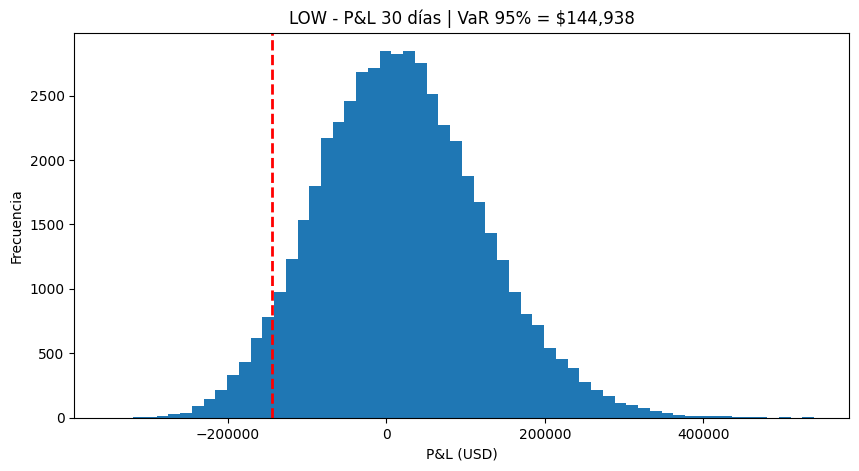


LOW:
VaR 95% en 30 días= $144,937.72 pérdida máxima estimada con 95% de confianza
CVaR 95% en 30 días= $181,035.62 pérdida promedio en el peor 5%


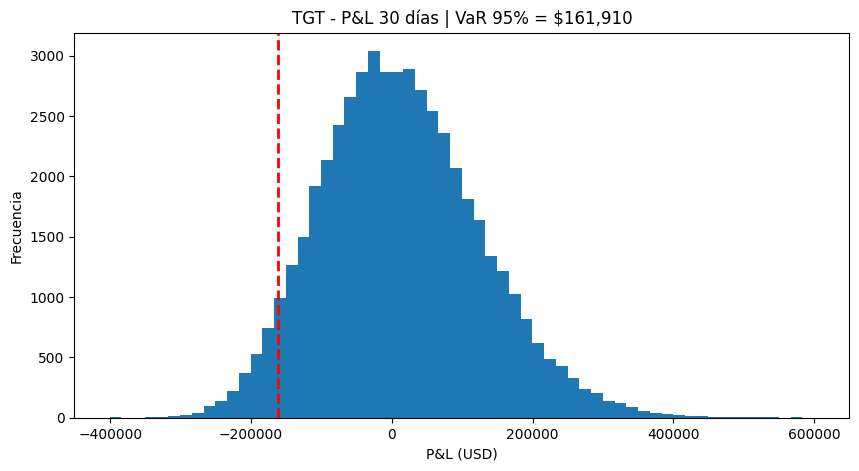


TGT:
VaR 95% en 30 días= $161,909.85 pérdida máxima estimada con 95% de confianza
CVaR 95% en 30 días= $197,641.39 pérdida promedio en el peor 5%


In [58]:

for ticker in ["LOW", "TGT"]:
    pnl = results[ticker]["pnl"]
    p5 = results[ticker]["p5"]
    var95 = results[ticker]["VaR95_30d"]

    plt.figure(figsize=(10,5))
    plt.hist(pnl, bins=60)
    plt.axvline(p5, color="red", linestyle="--", linewidth=2)
    plt.title(f"{ticker} - P&L 30 días | VaR 95% = ${var95:,.0f}")
    plt.xlabel("P&L (USD)")
    plt.ylabel("Frecuencia")
    plt.show()

    print(f"\n{ticker}:")
    print(f"VaR 95% en 30 días= ${var95:,.2f} pérdida máxima estimada con 95% de confianza")
    print(f"CVaR 95% en 30 días= ${results[ticker]['CVaR95_30d']:,.2f} pérdida promedio en el peor 5%")

In [59]:
best = min(["LOW", "TGT"], key=lambda t: results[t]["VaR95_30d"])

print("\nRecmendación.")
print(f"Para minimizar la pérdida, conviene invertir en: {best}")

if best == "LOW":
    print("Justificación: LOW presenta menor VaR 95% y menor CVaR 95%, indicando menor riesgo normal y menor riesgo extremo.")
else:
    print("Justificación: TGT presenta menor VaR 95% y menor CVaR 95%, indicando menor riesgo normal y menor riesgo extremo.")


Recmendación.
Para minimizar la pérdida, conviene invertir en: LOW
Justificación: LOW presenta menor VaR 95% y menor CVaR 95%, indicando menor riesgo normal y menor riesgo extremo.
